In [3]:
import numpy as np
import matplotlib.pyplot as plt
from bkm10 import BKM10
import pandas as pd
import tensorflow as tf

In [4]:
fn = 'finalised pseudodata.csv'
df = pd.read_csv(fn)

def get_bkm(set_num):
    
    df_set = df[df['set']==set_num]

    plus = BKM10(df_set['k'].values[0], df_set['Q2'].values[0], df_set['xB'].values[0], df_set['t'].values[0], helc=1)
    mins = BKM10(df_set['k'].values[0], df_set['Q2'].values[0], df_set['xB'].values[0], df_set['t'].values[0], helc=-1)
    
    cffs = df_set[['ReH','ReHt','ReE','ReEt','ImH','ImHt','ImE','ImEt']].to_numpy()[0]
    
    phi = np.linspace(min(df_set['phi']), max(df_set['phi']), 50)
    phi= np.pi-np.deg2rad(phi)
    phi = tf.convert_to_tensor(phi, dtype=tf.float32)

    return phi, plus, mins, cffs

def get_sig(phi, plus, mins, cffs):

    cffs = tf.convert_to_tensor(cffs, dtype=tf.float32)
    splus = plus.calculate_cross_section(phi, cffs).numpy()
    smins = mins.calculate_cross_section(phi, cffs).numpy()

    dsig = 0.5*(splus+smins)
    delsig = 0.5*(splus-smins)

    return dsig, delsig

In [32]:
def get_all_sig(set, index, N):

    phi, plus, mins, cffs = get_bkm(set)

    true_dsig, true_delsig = get_sig(phi, plus, mins, [cffs])

    dsig_all = [None]*N
    delsig_all = [None]*N

    x = cffs[index]
    cffs = np.tile(cffs, (N,1))
    cffs[:,index] = np.linspace(-abs(10*x), abs(10*x), N)

    for i in range(N):
        
        dsig, delsig = get_sig(phi, plus, mins, [cffs[i]])
        
        dsig_all[i] = dsig
        delsig_all[i] = delsig

    return phi, true_dsig, true_delsig, dsig_all, delsig_all 

def get_plot(set_, iters):
    names = ['ReH','ReHt','ReE','ReEt','ImH','ImHt','ImE','ImEt']
    fig, axs = plt.subplots(4,4,figsize=(12,10))
    fig.subplots_adjust(hspace=0.5, wspace=0.4)
    axs = axs.flatten()

    counter = 0

    for i in range(8):
        
        phi, true_dsig, true_delsig, dsig_all, delsig_all = get_all_sig(set_, i, iters)

        for j in range(np.shape(dsig_all)[0]):
            axs[counter].plot(phi, dsig_all[j], c='tab:blue', lw=0.5)
            axs[counter+1].plot(phi, delsig_all[j], c='tab:blue', lw=0.5)
            axs[counter].set_title(names[i])
            axs[counter+1].set_title(names[i])

        axs[counter].plot(phi, true_dsig, c='k', ls='--', lw=0.7)
        axs[counter+1].plot(phi, true_delsig, c='k', ls='--', lw=0.7)
        counter+=2


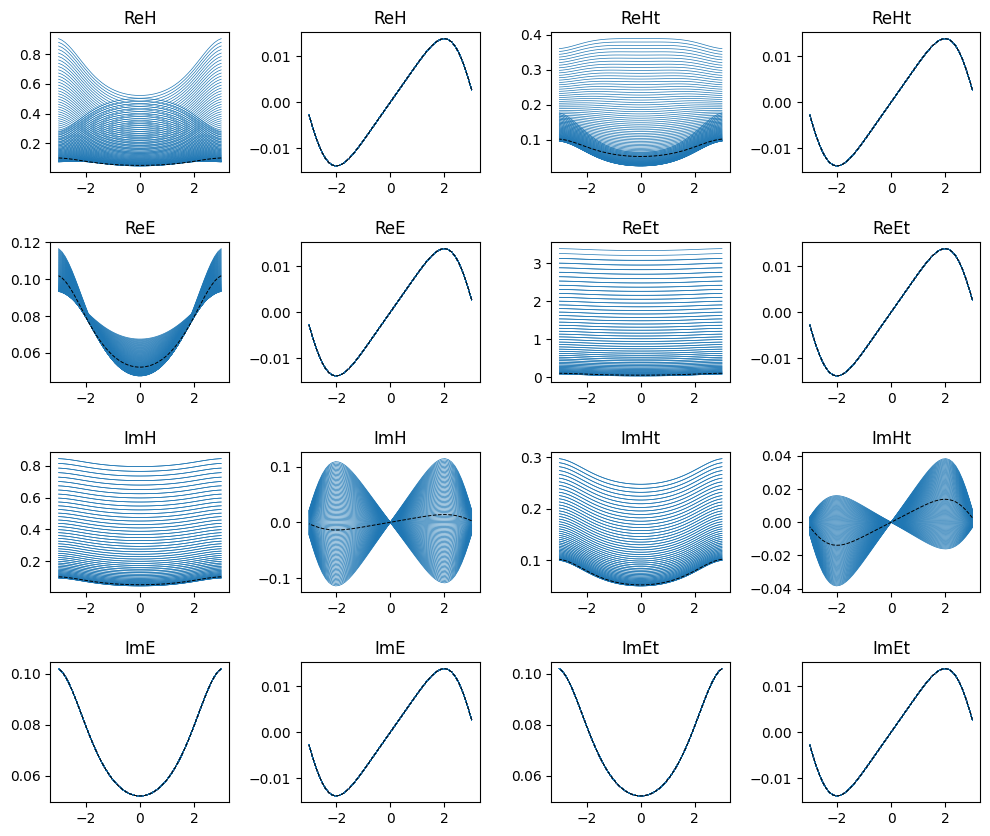

In [33]:
get_plot(4, iters=100)

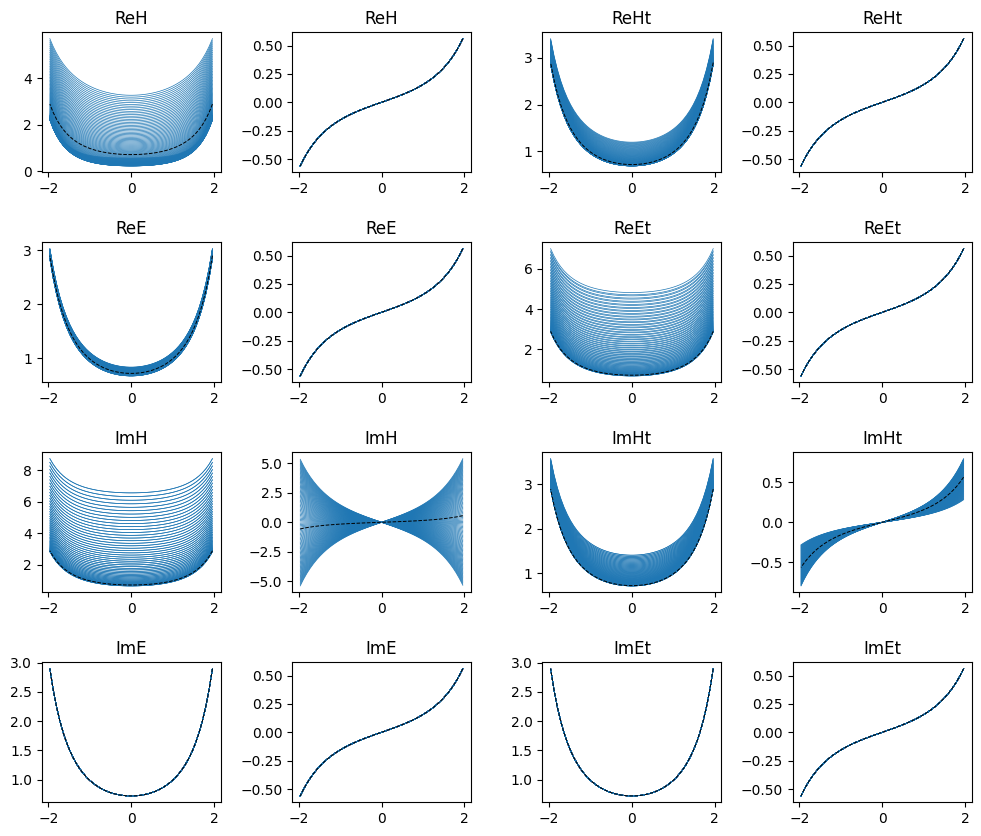

In [34]:
get_plot(25, iters=100)

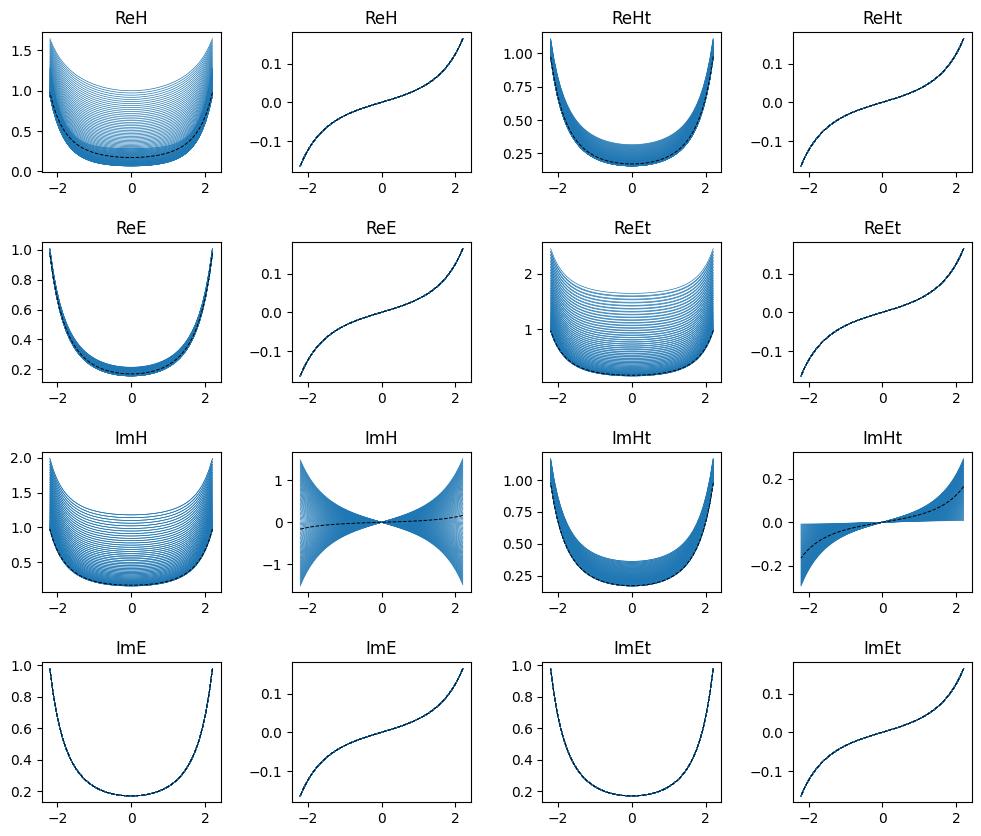

In [35]:
get_plot(50, iters=100)

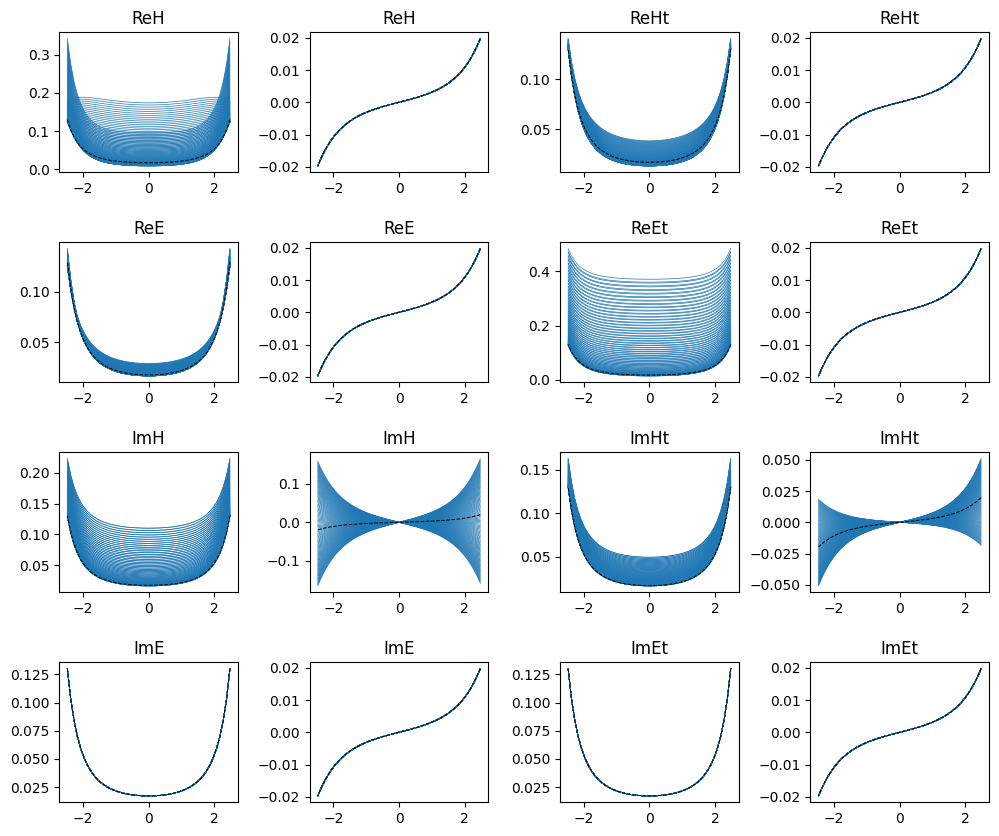

In [36]:
get_plot(100, iters=100)

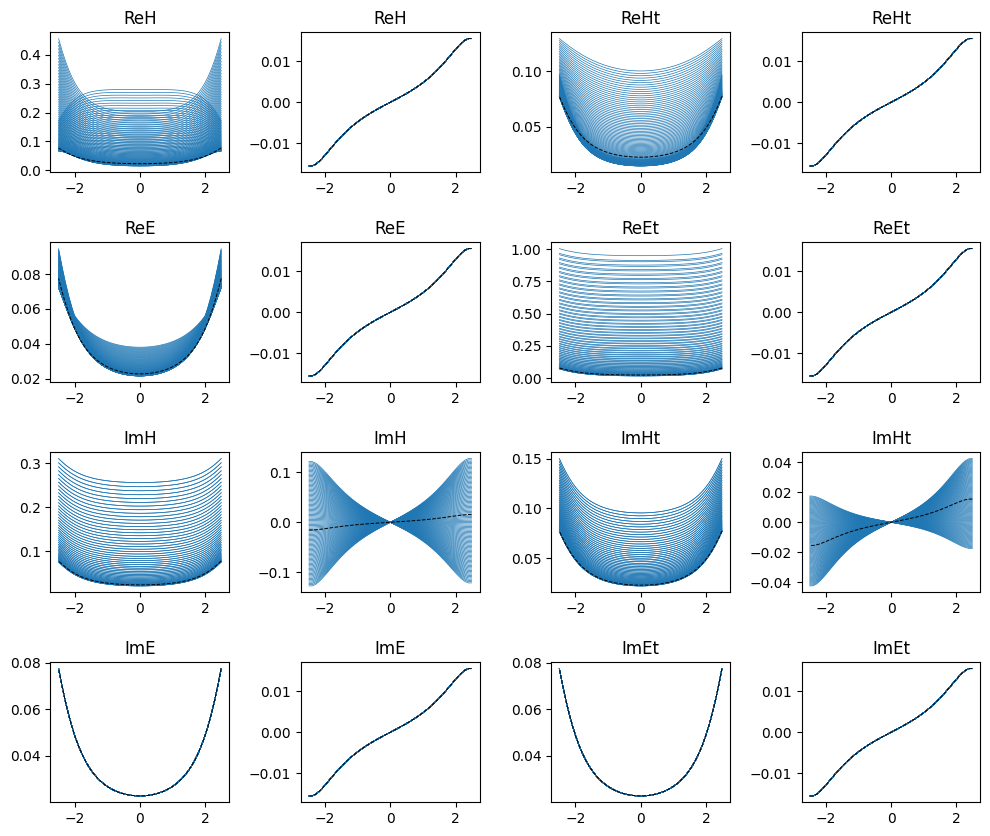

In [37]:
get_plot(150, iters=100)

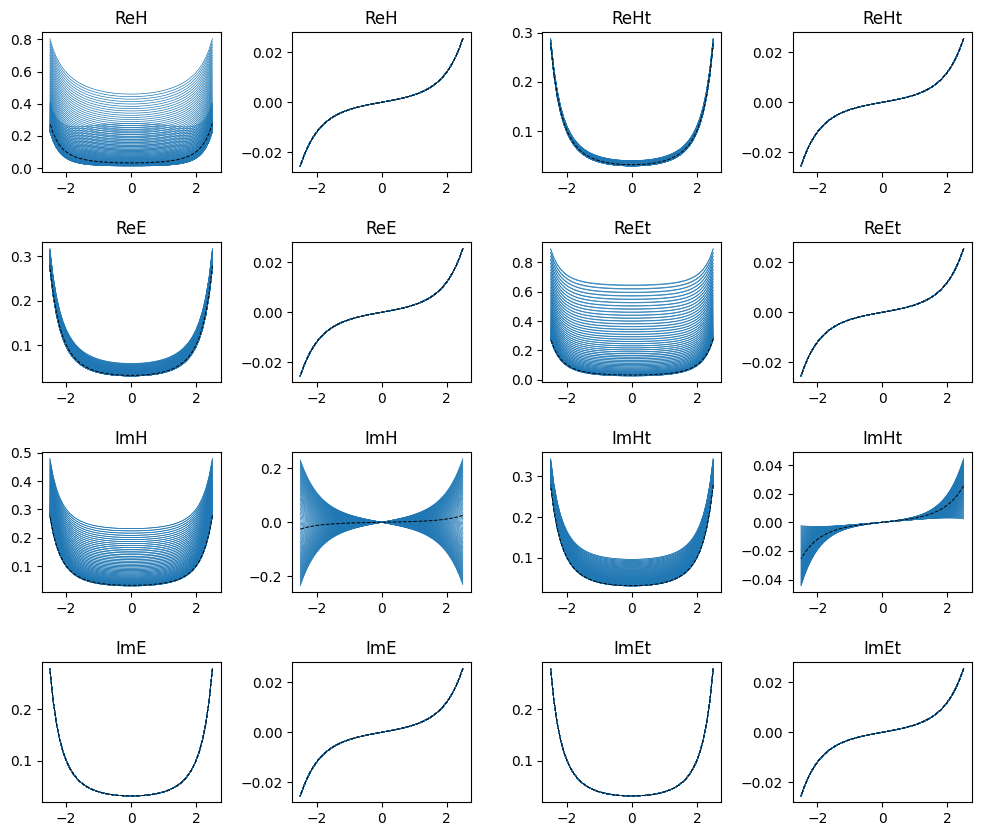

In [38]:
get_plot(200, iters=100)

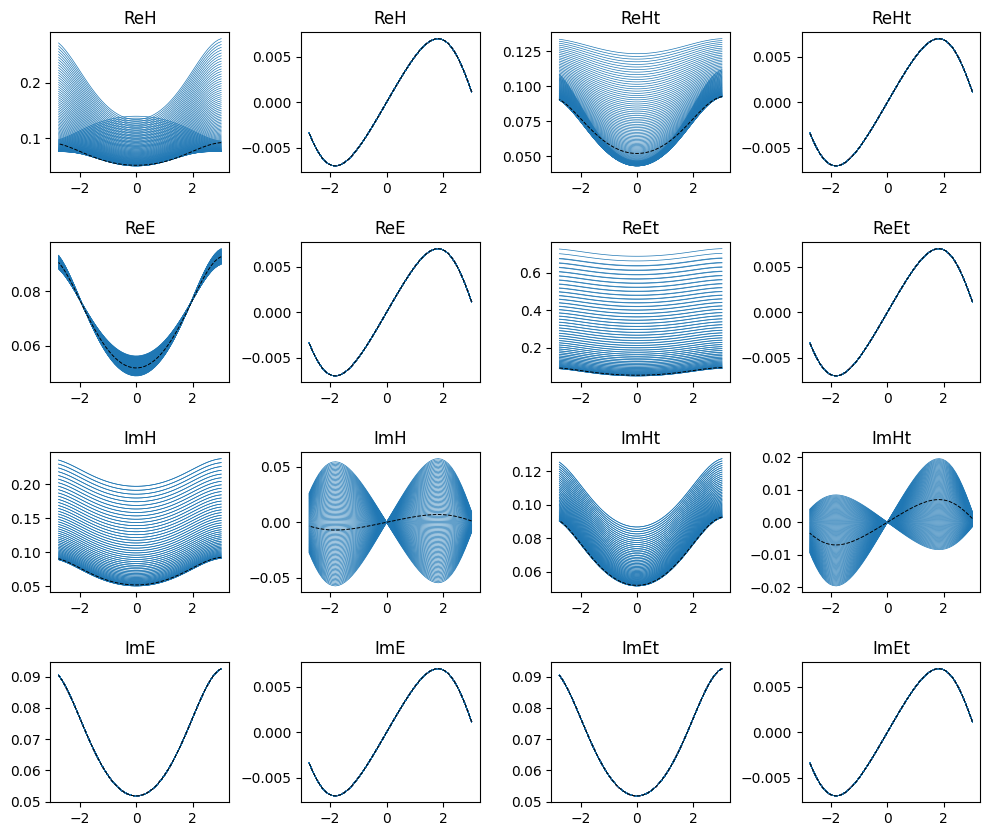

In [39]:
get_plot(300, iters=100)

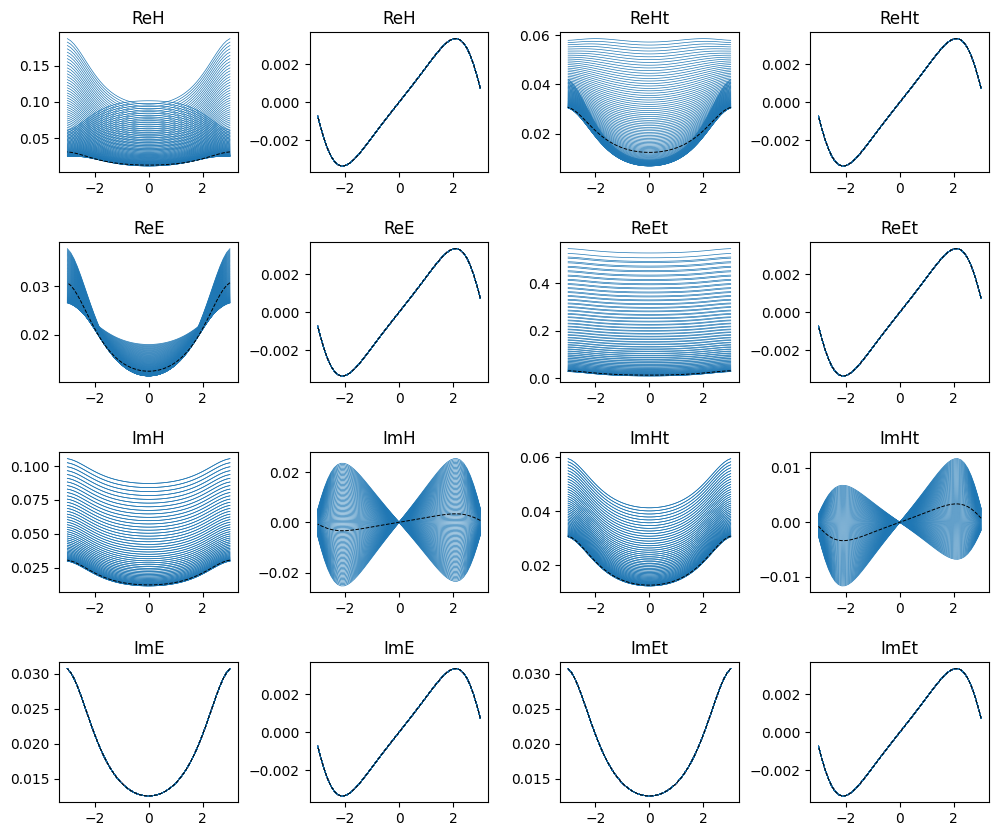

In [40]:
get_plot(350, iters=100)